<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/%D0%A1%D3%A8%D0%96_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #006064 0%, #00838f 50%, #0097a7 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">СӨЖ 20</h1>
  <p style="color:#e0f7fa; font-size:1em; margin:0;">Классификация · Детекция · Сегментация · Генерация · GradCAM · U-Net · GAN</p>
</div>

## Кіріспе

**Компьютерлік көру (Computer Vision)** — компьютерлердің сандық кескіндерден мағыналы ақпарат алуын зерттейтін жасанды интеллект саласы. Адам миы секундтар ішінде суреттен ондаған нысанды анықтайды; қазіргі терең оқыту модельдері осы міндетті одан да жылдам орындайды.

Бұл дəптер Computer Vision-дің төрт негізгі тапсырмасын бір жерде қамтиды. Əр тапсырма минималды, бірақ жұмыс жасайтын түрде іске асырылады. Кейін əр тапсырма өзінің бөлек зертханасында тереңірек зерттеледі.

| Тапсырма | Сұрақ | Шығыс |
|---|---|---|
| **Классификация** | Бұл не? | Тап + ықтималдық |
| **Детекция** | Қайда жəне не? | Bounding box + тап |
| **Сегментация** | Əр пиксель қай таптікі? | Пиксель маскасы |
| **Генерация** | Жаңа сурет жаса | Синтетикалық кескін |

## Оқу Мақсаттары

- CV-дің төрт негізгі тапсырмасын жəне олардың айырмасын түсіндіре аласыз
- CNN классификаторын үйретіп, GradCAM арқылы шешімді визуализациялай аласыз
- YOLO-стиль detekция принципін жəне Anchor box тұжырымдамасын сипаттай аласыз
- U-Net архитектурасын нөлден жасай аласыз
- DCGAN-ды үйретіп, синтетикалық кескін генерациялай аласыз
- Əр тапсырманың негізгі метрикасын (Top-1 Accuracy, mAP, IoU, FID) түсінесіз


## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input, decode_predictions
)

print("TensorFlow нұсқасы:", tf.__version__)
print("GPU бар ма:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow нұсқасы: 2.20.0
GPU бар ма: False


In [2]:
# ============================================================
### TODO ###
# Кездейсоқтықты бекітіңіз: tf.random.set_seed(42),
# np.random.seed(42)
# ============================================================
tf.random.set_seed(42)
np.random.seed(42)
print("Seed бекітілді.")

Seed бекітілді.


## 2-бөлім: CIFAR-10 Деректерін Жүктеу

CIFAR-10 — 10 санатты 32×32 пиксельді 60 000 түрлі-түсті суреттер жинағы. Барлық CV тапсырмалары осы жинақта демонстрацияланады.

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

CLASS_NAMES = ['ұшақ','автомобиль','құс','мысық','бұғы',
               'ит','бақа','ат','кеме','жүк машинасы']

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

y_train_flat = y_train.flatten()
y_test_flat  = y_test.flatten()

print("Үйрету:", x_train.shape, "Тест:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2274s 13us/step
Үйрету: (50000, 32, 32, 3) Тест: (10000, 32, 32, 3)


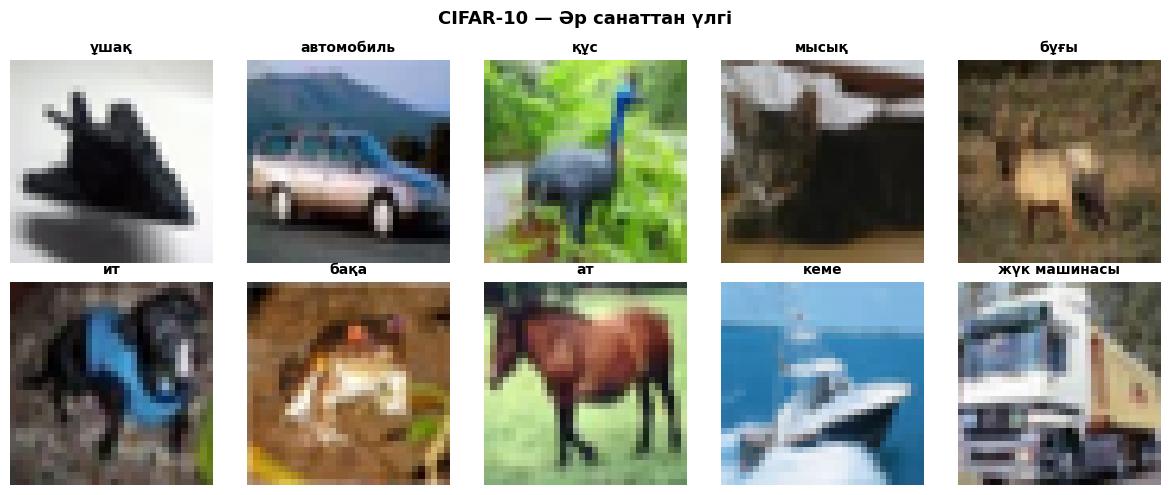

In [4]:
# ============================================================
### TODO ###
# CIFAR-10-нан əр санаттың бір суретін 2×5 торда бейнелеңіз.
# np.where(y_train_flat == i)[0][0] арқылы бірінші индексті алыңыз.
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 — Əр санаттан үлгі', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    idx = np.where(y_train_flat == i)[0][0]
    ax.imshow(x_train[idx])   # idx
    ax.set_title(CLASS_NAMES[i], fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3-бөлім: Тапсырма 1 — Кескін Классификациясы

Классификация — CV-дің ең негізгі тапсырмасы. CNN суреттен иерархиялық ерекшеліктерді (жиектер → текстуралар → пішіндер → объектілер) автоматты анықтайды.

In [5]:
# ============================================================
### TODO ###
# CNN классификаторын жасаңыз:
#   Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3))
#   BatchNormalization()
#   MaxPooling2D(2)
#   Conv2D(64, 3, padding='same', activation='relu')
#   BatchNormalization()
#   MaxPooling2D(2)
#   Conv2D(128, 3, padding='same', activation='relu')
#   GlobalAveragePooling2D()
#   Dense(10, activation='softmax')
# ============================================================
clf_model = keras.Sequential([
    layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(10, activation='softmax')
], name='CNN_Classifier')

clf_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
clf_model.summary()

Model: "CNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,922 (370.79 KB)

 Trainable params: 94,730 (370.04 KB)

 Non-trainable params: 192 (768.00 B)

In [6]:
print("CNN классификатор үйретілуде (10 дəуір)...")
history_clf = clf_model.fit(
    x_train_norm, y_train_flat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
_, test_acc = clf_model.evaluate(x_test_norm, y_test_flat, verbose=0)
print(f"Тест дəлдігі: {test_acc:.4f}")

CNN классификатор үйретілуде (10 дəуір)...
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 121s 336ms/step - accuracy: 0.4888 - loss: 1.4261 - val_accuracy: 0.1706 - val_loss: 3.2806
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 117s 333ms/step - accuracy: 0.6200 - loss: 1.0831 - val_accuracy: 0.5650 - val_loss: 1.1650
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 333ms/step - accuracy: 0.6649 - loss: 0.9563 - val_accuracy: 0.5894 - val_loss: 1.1290
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 116s 328ms/step - accuracy: 0.6956 - loss: 0.8728 - val_accuracy: 0.6674 - val_loss: 0.9267
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 142s 329ms/step - accuracy: 0.7196 - loss: 0.8055 - val_accuracy: 0.6684 - val_loss: 0.9307
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 331ms/step - accuracy: 0.7404 - loss: 0.7505 - val_accuracy: 0.7036 - val_loss: 0.8547
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 116s 329ms/step - accuracy: 0.7555 - loss: 0.7052 - val_accuracy: 0.7150 - val_loss: 0.8079
Epoch 8/10
352/352 ━━━━━━━━━━━━━━

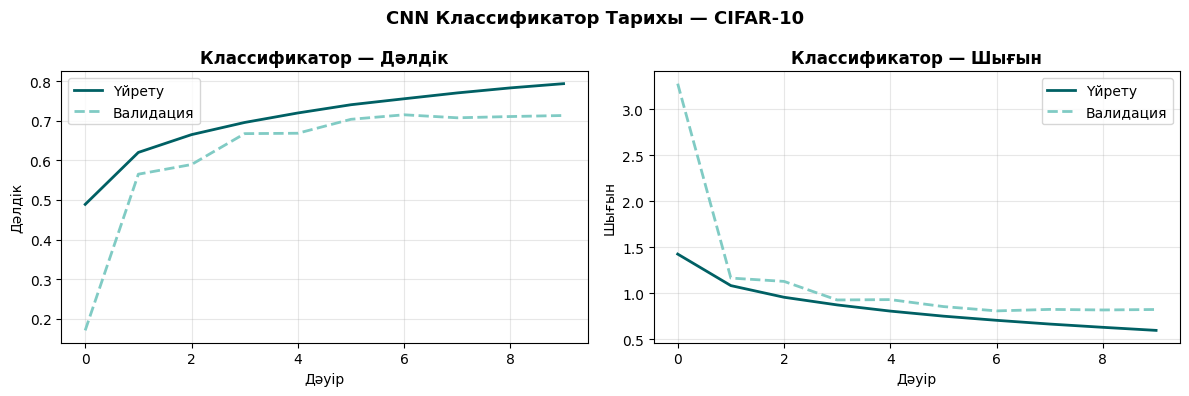

In [7]:
# ============================================================
### TODO ###
# Үйрету тарихын (accuracy + loss) 2 графикте бейнелеңіз.
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_clf.history['accuracy'], label='Үйрету', linewidth=2, color='#006064')
ax1.plot(history_clf.history['val_accuracy'], label='Валидация', linewidth=2, color='#80cbc4', linestyle='--')

ax1.set_title('Классификатор — Дəлдік', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дəуір')
ax1.set_ylabel('Дəлдік')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_clf.history['loss'], label='Үйрету', linewidth=2, color='#006064')
ax2.plot(history_clf.history['val_loss'], label='Валидация', linewidth=2, color='#80cbc4', linestyle='--')
ax2.set_title('Классификатор — Шығын', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дəуір')
ax2.set_ylabel('Шығын')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('CNN Классификатор Тарихы — CIFAR-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

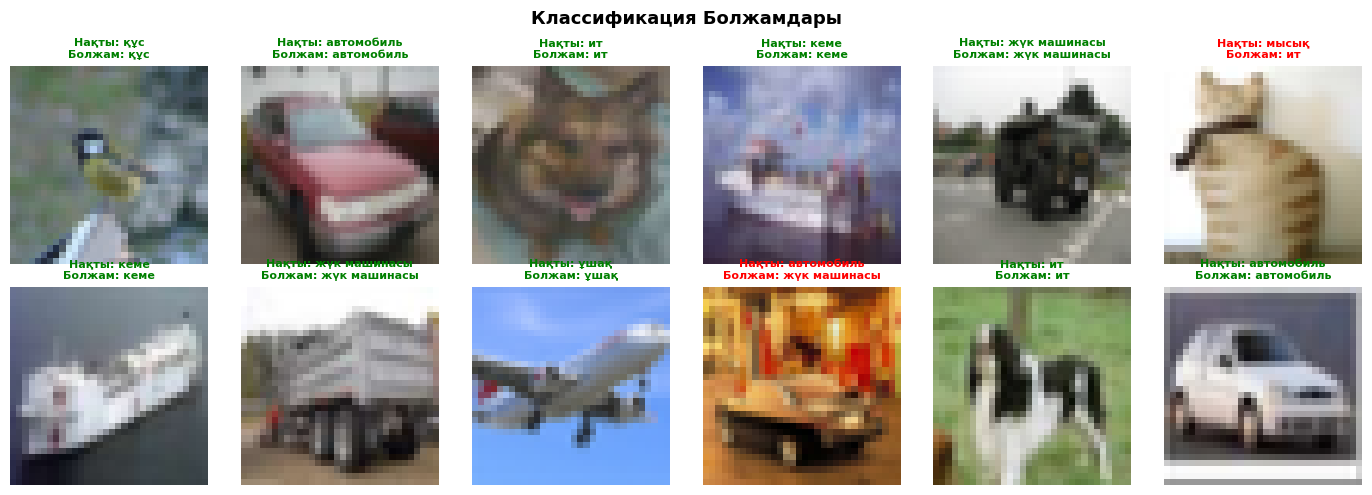

In [8]:
# ============================================================
### TODO ###
# Тест жинағынан 12 кездейсоқ сурет таңдап,
# болжамдарды (нақты / болжам) бейнелеңіз.
# Дұрыс болжам — жасыл, қате — қызыл тақырып.
# ============================================================
sample_idx = np.random.choice(len(x_test), 12, replace=False)
x_sample   = x_test_norm[sample_idx]
y_sample   = y_test_flat[sample_idx]

preds      = clf_model.predict(x_sample, verbose=0)
pred_cls = np.argmax(preds, axis=1)   # preds

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Классификация Болжамдары', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_test[sample_idx[i]])
    correct = pred_cls[i] == y_sample[i]
    color   = 'green' if correct else 'red'
    ax.set_title(
        f"Нақты: {CLASS_NAMES[y_sample[i]]}\nБолжам: {CLASS_NAMES[pred_cls[i]]}",
        color=color, fontsize=8, fontweight='bold'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4-бөлім: GradCAM — Модельдің «Назарын» Визуализациялау

**GradCAM** (Gradient-weighted Class Activation Mapping) — CNN-нің шешімін қабылдауда суреттің қай бөлігіне назар аударғанын жылу картасы арқылы бейнелейді. «Неге осылай классификацияланды?» сұрағына жауап береді.

In [12]:
def compute_gradcam(model, img, layer_name, class_idx):
    # model.input емес, model.inputs қолданамыз
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img, training=False)
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    if tf.reduce_max(heatmap) != 0:
        heatmap = heatmap / tf.reduce_max(heatmap)

    return heatmap.numpy()

print("compute_gradcam() анықталды.")

compute_gradcam() анықталды.


In [11]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Модельді нақты input-пен бір рет шақырамыз
dummy = tf.zeros((1,) + x_test_norm.shape[1:])
_ = clf_model(dummy, training=False)

print("Model built:", clf_model.built)
print("Input shape:", x_test_norm.shape[1:])

Model built: True
Input shape: (32, 32, 3)


Соңғы Conv2D қабаты: conv2d_2


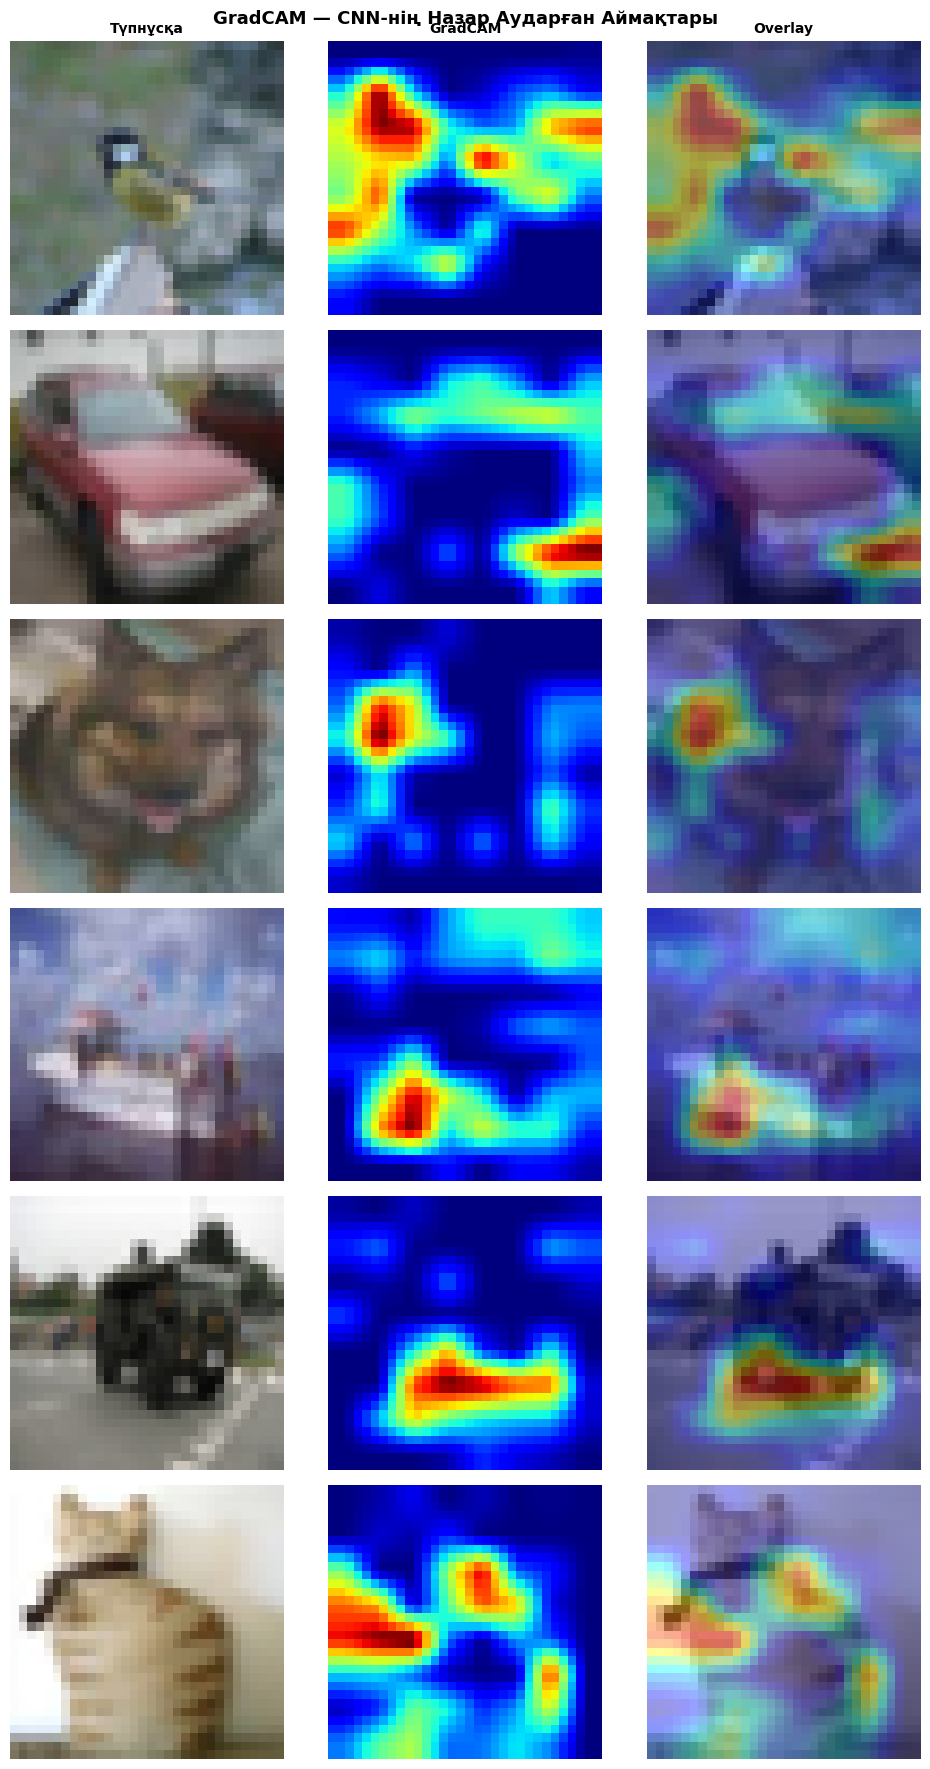

In [13]:
# ============================================================
### TODO ###
# GradCAM-ды 6 тест суретіне қолданыңыз.
# Соңғы Conv2D қабатының атын clf_model.layers арқылы анықтаңыз.
# Əр сурет үшін: түпнұсқа + GradCAM жылу картасы + overlay.
# ============================================================

# Соңғы Conv2D қабатын табамыз
last_conv = [l.name for l in clf_model.layers if 'conv' in l.name][-1]
print("Соңғы Conv2D қабаты:", last_conv)

sample_gradcam = sample_idx[:6]
fig, axes = plt.subplots(6, 3, figsize=(10, 18))
fig.suptitle('GradCAM — CNN-нің Назар Аударған Аймақтары',
             fontsize=13, fontweight='bold')

col_titles = ['Түпнұсқа', 'GradCAM', 'Overlay']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=10, fontweight='bold')

for i, idx in enumerate(sample_gradcam):
    img      = x_test_norm[idx:idx+1]
    pred_i   = np.argmax(clf_model.predict(img, verbose=0)[0])
    heatmap  = compute_gradcam(clf_model, img, last_conv, pred_i)

    # Жылу картасын сурет өлшеміне дейін үлкейтеміз
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], [32, 32]
    ).numpy().squeeze()

    # Overlay: сурет + жылу картасы
    import cv2 as _cv2
    try:
        hm_uint8  = np.uint8(255 * heatmap_resized)
        hm_color  = _cv2.applyColorMap(hm_uint8, _cv2.COLORMAP_JET)
        hm_color  = _cv2.cvtColor(hm_color, _cv2.COLOR_BGR2RGB) / 255.0
        overlay   = 0.6 * x_test[idx] / 255.0 + 0.4 * hm_color
        overlay   = np.clip(overlay, 0, 1)
    except ImportError:
        overlay = x_test[idx] / 255.0

    axes[i, 0].imshow(x_test[idx])
    axes[i, 0].set_ylabel(
        f"{CLASS_NAMES[pred_i]}", fontsize=9, fontweight='bold'
    )
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap_resized, cmap='jet')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## 5-бөлім: Тапсырма 2 — Объект Детекциясы

Детекция классификациядан күрделірек: сурет ішінде **бірнеше** объектінің **орнын** (bounding box) жəне **типін** анықтайды.

Негізгі метрика — **mAP** (mean Average Precision):
```
IoU = Intersection Area / Union Area
```
Детекция дұрыс деп саналу үшін: IoU ≥ 0.5 (PASCAL VOC) немесе ≥ 0.75 (COCO)

In [14]:
# Bounding box IoU есептейтін функция
def compute_iou(box1, box2):
    """
    Екі bounding box-тың IoU-ін есептейді.
    box = [x1, y1, x2, y2] форматы (сол-жоғары, оң-төменгі бұрыш)
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - intersection

    return intersection / (union + 1e-10)

print("compute_iou() анықталды.")

compute_iou() анықталды.


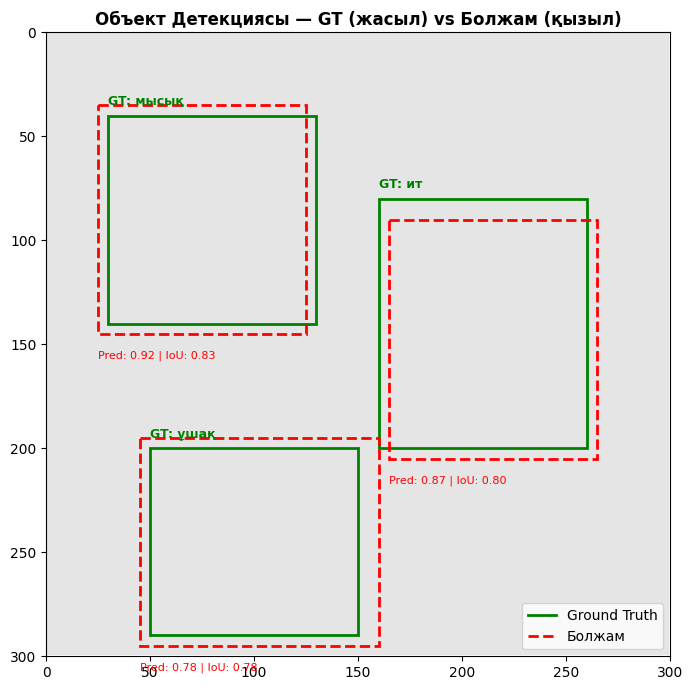

Box 1 (мысық): IoU = 0.8261 ✓
Box 2 (ит): IoU = 0.8008 ✓
Box 3 (ұшақ): IoU = 0.7826 ✓


In [15]:
# ============================================================
### TODO ###
# Синтетикалық суретте детекция нəтижелерін визуализациялаңыз.
# gt_boxes — нақты bounding boxтар (Ground Truth)
# pred_boxes — болжамдар
# Əр жұп үшін IoU есептеп, жасыл (GT) / қызыл (pred) box сызыңыз.
# ============================================================

# Синтетикалық детекция мысалы
np.random.seed(10)
img_size  = 300
demo_img  = np.ones((img_size, img_size, 3), dtype=np.float32) * 0.9

# Ground Truth boxes [x1, y1, x2, y2]
gt_boxes = [
    [30,  40,  130, 140, 'мысық'],
    [160, 80,  260, 200, 'ит'],
    [50,  200, 150, 290, 'ұшақ'],
]
# Болжанған boxтар
pred_boxes = [
    [25,  35,  125, 145, 0.92],
    [165, 90,  265, 205, 0.87],
    [45,  195, 160, 295, 0.78],
]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(demo_img)

# Ground Truth — жасыл
for box in gt_boxes:
    x1, y1, x2, y2, label = box
    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor='green', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(x1, y1-5, f'GT: {label}',
            color='green', fontsize=9, fontweight='bold')

# Болжам — қызыл + IoU
for i, pbox in enumerate(pred_boxes):
    x1, y1, x2, y2, score = pbox
    gt = gt_boxes[i][:4]
    iou = compute_iou([x1,y1,x2,y2], gt)

    rect = patches.Rectangle(
        (x1, y1), x2-x1, y2-y1,
        linewidth=2, edgecolor='red',
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(x1, y2+12, f'Pred: {score:.2f} | IoU: {iou:.2f}',
            color='red', fontsize=8)

ax.set_xlim(0, img_size)
ax.set_ylim(img_size, 0)
ax.set_title('Объект Детекциясы — GT (жасыл) vs Болжам (қызыл)',
             fontsize=12, fontweight='bold')
from matplotlib.lines import Line2D
legend = [
    Line2D([0],[0], color='green', linewidth=2, label='Ground Truth'),
    Line2D([0],[0], color='red',   linewidth=2, linestyle='--', label='Болжам'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

for i, (gt, pred) in enumerate(zip(gt_boxes, pred_boxes)):
    iou = compute_iou(pred[:4], gt[:4])
    print(f"Box {i+1} ({gt[4]}): IoU = {iou:.4f} {'✓' if iou>=0.5 else '✗'}")

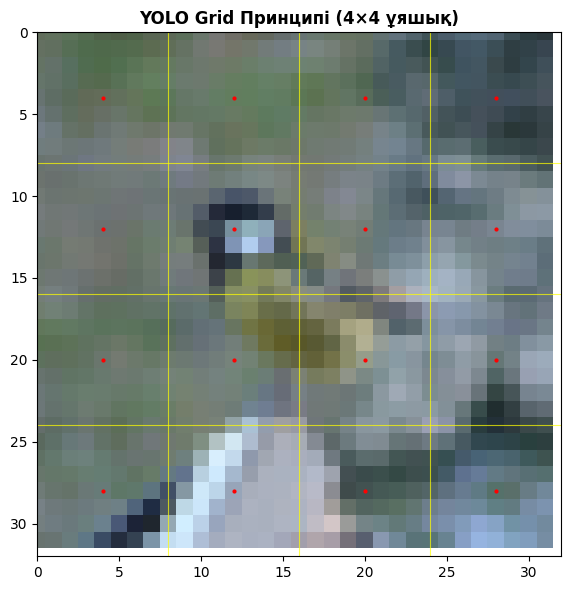

YOLO 4×4 grid: 16 ұяшық, əрқайсысы болжам жасайды.


In [16]:
# YOLO Grid архитектурасын визуализациялаймыз
grid_size = 4
fig, ax   = plt.subplots(figsize=(6, 6))
ax.imshow(x_test[sample_idx[0]])
ax.set_xlim(0, 32)
ax.set_ylim(32, 0)

# Grid сызықтары
cell_size = 32 / grid_size
for i in range(1, grid_size):
    ax.axhline(i * cell_size, color='yellow', linewidth=0.8, alpha=0.7)
    ax.axvline(i * cell_size, color='yellow', linewidth=0.8, alpha=0.7)

# Əр ұяшыққа anchor box орналастырамыз
for row in range(grid_size):
    for col in range(grid_size):
        cx = (col + 0.5) * cell_size
        cy = (row + 0.5) * cell_size
        ax.plot(cx, cy, 'r.', markersize=4)

ax.set_title(f'YOLO Grid Принципі ({grid_size}×{grid_size} ұяшық)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"YOLO {grid_size}×{grid_size} grid: {grid_size**2} ұяшық, əрқайсысы болжам жасайды.")

## 6-бөлім: Тапсырма 3 — Сегментация

Сегментация — əр пиксельге тап береді. Детекциядан айырмасы: bounding box емес, нақты объект пішімі анықталады.

| Тип | Сипаты |
|---|---|
| **Семантикалық** | Əр пиксель → тап (бірдей класс — бір рəң) |
| **Инстанция** | Əр объект — жеке нысан (2 мысық — 2 маска) |
| **Паноптикалық** | Семантикалық + Инстанция біріктірілген |

In [17]:
# Минималды U-Net архитектурасы
def build_mini_unet(input_shape=(32, 32, 3), num_classes=1):
    """
    Кіші U-Net: Encoder → Bottleneck → Decoder (Skip connections)
    """
    inputs = keras.Input(shape=input_shape)

    # ── Encoder ──────────────────────────────────────────────
    e1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    e1 = layers.Conv2D(32, 3, activation='relu', padding='same')(e1)
    p1 = layers.MaxPooling2D(2)(e1)   # 16×16

    e2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    e2 = layers.Conv2D(64, 3, activation='relu', padding='same')(e2)
    p2 = layers.MaxPooling2D(2)(e2)   # 8×8

    # ── Bottleneck ───────────────────────────────────────────
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(b)

    # ── Decoder ──────────────────────────────────────────────
    u2 = layers.UpSampling2D(2)(b)              # 16×16
    u2 = layers.Concatenate()([u2, e2])          # Skip connection
    d2 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)

    u1 = layers.UpSampling2D(2)(d2)             # 32×32
    u1 = layers.Concatenate()([u1, e1])          # Skip connection
    d1 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(d1)

    return keras.Model(inputs, outputs, name='Mini_UNet')

unet = build_mini_unet()
unet.summary()

Model: "Mini_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      9,248 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     36,928 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 64)  │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8, 128) │    147,584 │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 16, 16,    │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32, 32,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32, 1) │         33 │ conv2d_10[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,377 (1.62 MB)

 Trainable params: 425,377 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

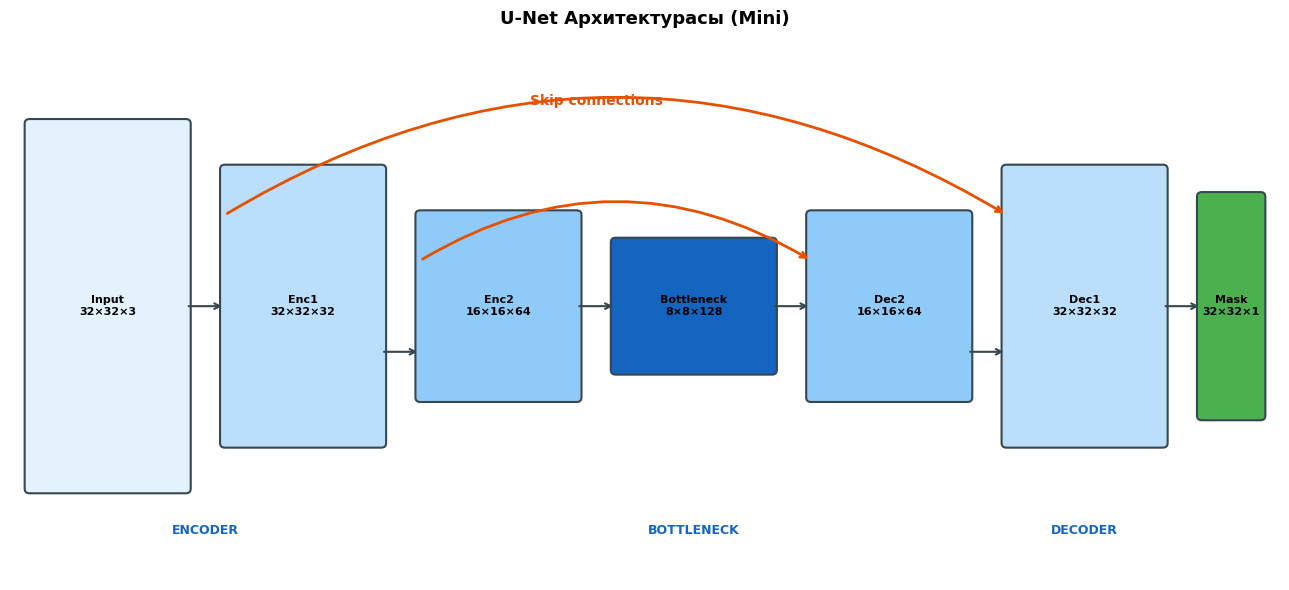

In [18]:
# ============================================================
### TODO ###
# U-Net архитектурасын schematic диаграммада бейнелеңіз.
# Encoder (сол), Bottleneck (орта), Decoder (оң), Skip (жоғарғы)
# жəне əр кезеңдегі feature map өлшемін жазыңыз.
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_title('U-Net Архитектурасы (Mini)',
             fontsize=13, fontweight='bold')

# Блоктар: (x_left, y_bottom, width, height, label, color)
blocks = [
    (0.2, 1.0, 1.6, 4.0, 'Input\n32×32×3',  '#e3f2fd'),
    (2.2, 1.5, 1.6, 3.0, 'Enc1\n32×32×32',  '#bbdefb'),
    (4.2, 2.0, 1.6, 2.0, 'Enc2\n16×16×64',  '#90caf9'),
    (6.2, 2.3, 1.6, 1.4, 'Bottleneck\n8×8×128','#1565c0'),
    (8.2, 2.0, 1.6, 2.0, 'Dec2\n16×16×64',  '#90caf9'),
    (10.2,1.5, 1.6, 3.0, 'Dec1\n32×32×32',  '#bbdefb'),
    (12.2,1.8, 0.6, 2.4, 'Mask\n32×32×1',   '#4caf50'),
]

for x, y, w, h, label, color in blocks:
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.05',
        facecolor=color, edgecolor='#37474f', linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label,
            ha='center', va='center', fontsize=8, fontweight='bold')

# Жебелер
arrow_pairs = [
    (1.8,3.0, 2.2,3.0), (3.8,2.5, 4.2,2.5), (5.8,3.0, 6.2,3.0),
    (7.8,3.0, 8.2,3.0), (9.8,2.5, 10.2,2.5),(11.8,3.0,12.2,3.0),
]
for x1,y1,x2,y2 in arrow_pairs:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#37474f', lw=1.5))

# Skip connections
ax.annotate('', xy=(10.2,4.0), xytext=(2.2,4.0),
            arrowprops=dict(arrowstyle='->', color='#e65100', lw=2,
                            connectionstyle='arc3,rad=-0.3'))
ax.annotate('', xy=(8.2,3.5), xytext=(4.2,3.5),
            arrowprops=dict(arrowstyle='->', color='#e65100', lw=2,
                            connectionstyle='arc3,rad=-0.3'))
ax.text(6.0, 5.2, 'Skip connections', ha='center',
        color='#e65100', fontsize=10, fontweight='bold')

ax.text(2.0, 0.5, 'ENCODER', ha='center', fontsize=9,
        color='#1565c0', fontweight='bold')
ax.text(7.0, 0.5, 'BOTTLENECK', ha='center', fontsize=9,
        color='#1565c0', fontweight='bold')
ax.text(11.0,0.5, 'DECODER', ha='center', fontsize=9,
        color='#1565c0', fontweight='bold')

plt.tight_layout()
plt.show()

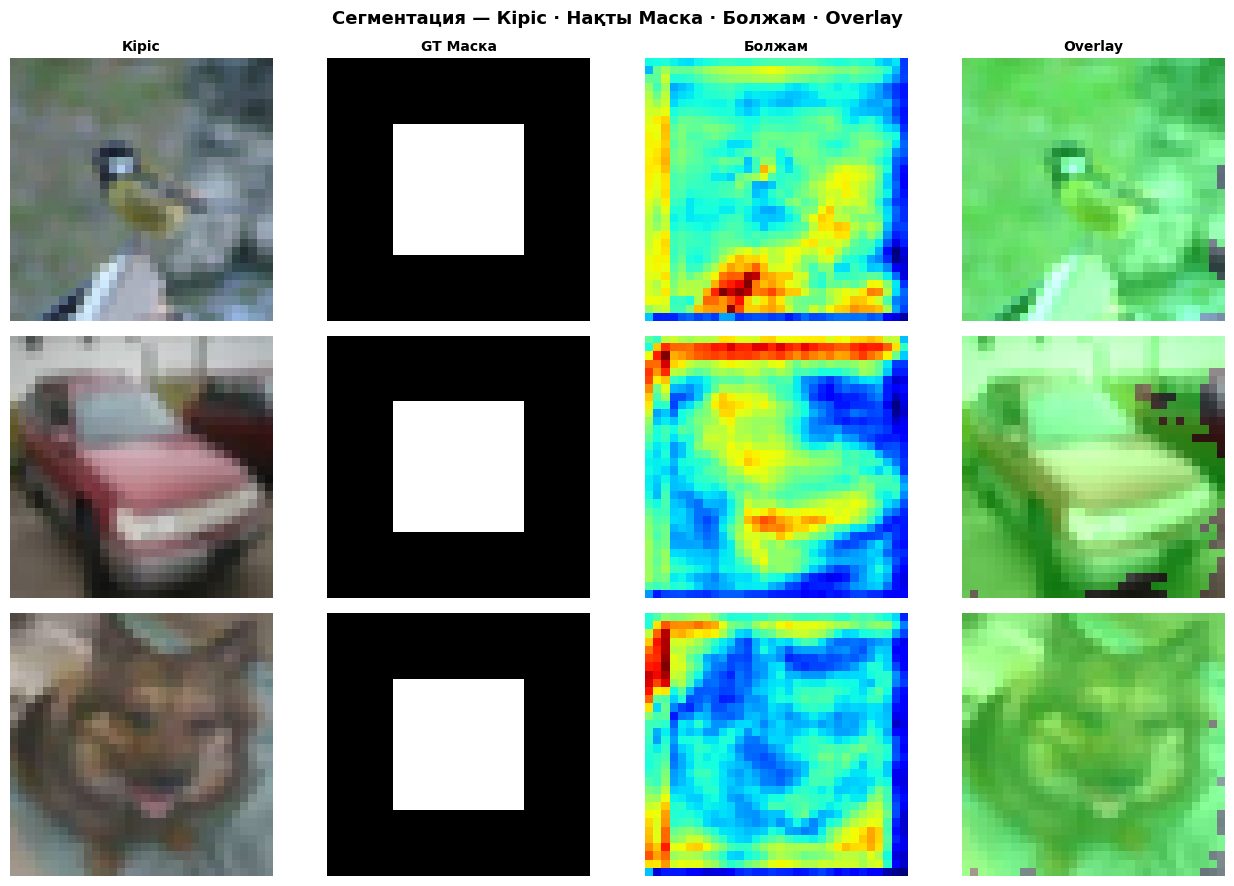

In [19]:
# Синтетикалық сегментация нəтижесін демонстрациялаймыз
# (нақты үйретусіз — принципті көрсету үшін)
np.random.seed(77)

fig, axes = plt.subplots(3, 4, figsize=(13, 9))
fig.suptitle('Сегментация — Кіріс · Нақты Маска · Болжам · Overlay',
             fontsize=13, fontweight='bold')

for row in range(3):
    idx   = sample_idx[row]
    img   = x_test[idx]

    # Синтетикалық маска (əлі үйретілмеген)
    gt_mask   = np.zeros((32, 32), dtype=np.float32)
    gt_mask[8:24, 8:24] = 1.0
    pred_mask = unet.predict(
        x_test_norm[idx:idx+1], verbose=0
    )[0, :, :, 0]
    pred_binary = (pred_mask > 0.5).astype(np.float32)

    # Overlay
    overlay = img.copy().astype(np.float32) / 255.0
    overlay[..., 1] = np.clip(
        overlay[..., 1] + 0.4 * pred_binary, 0, 1
    )

    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(CLASS_NAMES[y_test_flat[idx]], fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(gt_mask, cmap='gray')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(pred_mask, cmap='jet')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(overlay)
    axes[row, 3].axis('off')

col_titles = ['Кіріс', 'GT Маска', 'Болжам', 'Overlay']
for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7-бөлім: Тапсырма 4 — Кескін Генерациясы

Кескін генерациясы — жаңа, нақты суреттерге ұқсас синтетикалық кескіндер жасайды:

| Əдіс | Принцип |
|---|---|
| **GAN** | Generator vs Discriminator |
| **VAE** | Latent кеңістіктен сэмплдеу |
| **Diffusion** | Шудан кері барып сурет жасау |
| **Style Transfer** | Контент + стиль суреттерін біріктіру |

In [20]:
LATENT_DIM = 128

def build_generator(latent_dim):
    """DCGAN Generator: кездейсоқ шудан → 32×32×3 сурет."""
    return keras.Sequential([
        layers.Dense(8 * 8 * 128, input_shape=(latent_dim,)),
        layers.Reshape((8, 8, 128)),
        layers.Conv2DTranspose(64, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(32, 4, strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(3, 3, padding='same', activation='tanh'),
    ], name='DCGAN_Generator')

def build_discriminator():
    """DCGAN Discriminator: 32×32×3 сурет → нақты/жалған."""
    return keras.Sequential([
        layers.Conv2D(32, 4, strides=2, padding='same', input_shape=(32,32,3)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(64, 4, strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid'),
    ], name='DCGAN_Discriminator')

generator     = build_generator(LATENT_DIM)
discriminator = build_discriminator()

print("Generator:")
generator.summary()
print("\nDiscriminator:")
discriminator.summary()

Generator:


Model: "DCGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,955 (4.66 MB)

 Trainable params: 1,221,763 (4.66 MB)

...

Model: "DCGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,497 (150.38 KB)

 Trainable params: 38,497 (150.38 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# ============================================================
### TODO ###
# GAN классын анықтаңыз (ЗЖ 2-ден таныс).
#   d_optimizer: Adam(lr=0.0002, beta_1=0.5)
#   g_optimizer: Adam(lr=0.0002, beta_1=0.5)
#   loss_fn: BinaryCrossentropy()
# Деректерді [-1, 1] диапазонына нормализациялаңыз.
# ============================================================
x_gan = (x_train.astype('float32') - 127.5) / 127.5

class DCGAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator     = generator
        self.discriminator = discriminator
        self.latent_dim    = latent_dim
        self.d_loss_tracker = keras.metrics.Mean(name='d_loss')
        self.g_loss_tracker = keras.metrics.Mean(name='g_loss')

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn     = loss_fn

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        noise      = tf.random.normal([batch_size, self.latent_dim])

        # Discriminator үйрету
        fake_images = self.generator(noise, training=False)
        combined    = tf.concat([real_images, fake_images], axis=0)
        labels      = tf.concat([
            tf.ones((batch_size, 1)),
            tf.zeros((batch_size, 1))
        ], axis=0)
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        with tf.GradientTape() as tape:
            preds  = self.discriminator(combined, training=True)
            d_loss = self.loss_fn(labels, preds)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Generator үйрету
        noise      = tf.random.normal([batch_size, self.latent_dim])
        misleading = tf.ones((batch_size, 1))
        with tf.GradientTape() as tape:
            fake  = self.generator(noise, training=True)
            preds = self.discriminator(fake, training=False)
            g_loss = self.loss_fn(misleading, preds)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(
            zip(grads, self.generator.trainable_weights)
        )

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {'d_loss': self.d_loss_tracker.result(),
                'g_loss': self.g_loss_tracker.result()}

dcgan = DCGAN(generator, discriminator, LATENT_DIM)
dcgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy()
)
print("DCGAN компиляцияланды.")

DCGAN компиляцияланды.


In [22]:
print("DCGAN үйретілуде (20 дəуір)...")
history_gan = dcgan.fit(
    x_gan,
    epochs=20,
    batch_size=128,
    verbose=1
)
print("Аяқталды.")

DCGAN үйретілуде (20 дəуір)...
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 362s 913ms/step - d_loss: 1.3335 - g_loss: 0.3224
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 381s 912ms/step - d_loss: 5.2860 - g_loss: 0.1290
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 382s 911ms/step - d_loss: 1.1580 - g_loss: 0.0909
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 380s 906ms/step - d_loss: 3.3910 - g_loss: 0.2091
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 386s 916ms/step - d_loss: 2.0633 - g_loss: 0.0817
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 358s 915ms/step - d_loss: 1.5375 - g_loss: 0.1276
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 379s 908ms/step - d_loss: 1.2597 - g_loss: 0.2023
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 385s 915ms/step - d_loss: 1.0727 - g_loss: 0.2658
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 384s 919ms/step - d_loss: 0.8533 - g_loss: 0.2562
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 358s 915ms/step - d_loss: 0.7674 - g_loss: 0.2716
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 357s 912ms/step - d_loss: 0

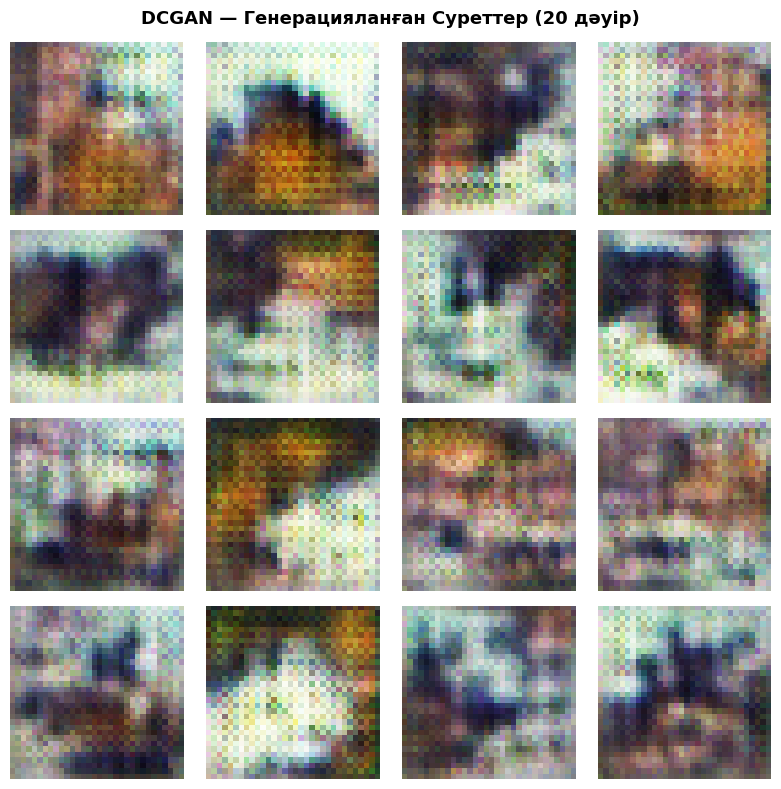

In [23]:
# ============================================================
### TODO ###
# Generator-дан 16 кездейсоқ сурет генерациялаңыз.
# tf.random.normal([16, LATENT_DIM]) арқылы шу жасаңыз.
# Суреттерді 4×4 торда бейнелеңіз.
# [-1,1] → [0,255] ауыстыруды ұмытпаңыз.
# ============================================================
noise_final = tf.random.normal([16, LATENT_DIM]) # 16
gen_imgs    = generator(noise_final, training=False).numpy()
gen_imgs    = ((gen_imgs + 1) / 2.0 * 255).astype(np.uint8)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle(f'DCGAN — Генерацияланған Суреттер (20 дəуір)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(gen_imgs[i])   # gen_imgs
    ax.axis('off')

plt.tight_layout()
plt.show()

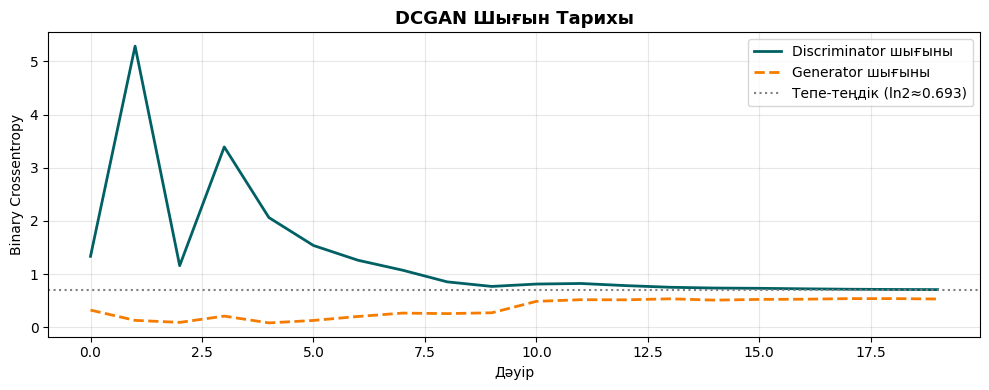

In [24]:
# GAN шығын тарихы
d_losses = history_gan.history['d_loss']
g_losses = history_gan.history['g_loss']

plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator шығыны', linewidth=2, color='#006064')
plt.plot(g_losses, label='Generator шығыны',     linewidth=2, color='#f57c00', linestyle='--')
plt.axhline(y=0.693, color='gray', linestyle=':', linewidth=1.5,
            label='Тепе-теңдік (ln2≈0.693)')
plt.title('DCGAN Шығын Тарихы', fontsize=13, fontweight='bold')
plt.xlabel('Дəуір')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8-бөлім: CV Тапсырмалары Метрикалары

Əр тапсырманың өзіне тəн бағалау метрикасы бар:

In [1]:
# ============================================================
### TODO ###
# Метрикалар кестесін толтырыңыз.
# Əр тапсырма үшін: метрика аты, формуласы, жоғары мəн = жақсы па?
# ============================================================
import pandas as pd

metrics_df = pd.DataFrame([
    {
        'Тапсырма':  'Классификация',
        'Метрика':   'Top-1 Accuracy',
        'Формула':   'Дұрыс / Жалпы',
        'Жоғары=Жақсы': True,
        'Модельдер': 'ResNet, VGG, EfficientNet'
    },
    {
        'Тапсырма':  'Детекция',
        'Метрика':   'mAP (mean AP)',
        'Формула':   'Орт. Avg Precision (IoU≥0.5)',
        'Жоғары=Жақсы': True,
        'Модельдер': 'YOLO, Faster R-CNN, SSD'
    },
    {
        'Тапсырма':  'Сегментация',
        'Метрика':   'mIoU / Dice',
        'Формула':   'Mean IoU немесе 2·TP/(2TP+FP+FN)',
        'Жоғары=Жақсы': True,
        'Модельдер': 'U-Net, DeepLab, Mask R-CNN'
    },
    {
        'Тапсырма':  'Генерация',
        'Метрика':   'FID (Frechet Inception Distance)',
        'Формула':   'Нақты мен жалған үлестірімінің айырмасы',
        'Жоғары=Жақсы': False,
        'Модельдер': 'DCGAN, StyleGAN, Diffusion'
    },
])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
print(metrics_df.to_string(index=False))

     Тапсырма                          Метрика                                 Формула  Жоғары=Жақсы                  Модельдер
Классификация                   Top-1 Accuracy                           Дұрыс / Жалпы          True  ResNet, VGG, EfficientNet
     Детекция                    mAP (mean AP)            Орт. Avg Precision (IoU≥0.5)          True    YOLO, Faster R-CNN, SSD
  Сегментация                      mIoU / Dice        Mean IoU немесе 2·TP/(2TP+FP+FN)          True U-Net, DeepLab, Mask R-CNN
    Генерация FID (Frechet Inception Distance) Нақты мен жалған үлестірімінің айырмасы         False DCGAN, StyleGAN, Diffusion


## 9-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** Классификация мен детекцияның архитектуралық айырмасы неде? Детекция неліктен күрделірек?

> Классификация суретте қандай объект бар екенін ғана анықтайды. Мысалы, сурет “мысық” деп жауап береді. Ал детекция объектінің класын да, суреттегі нақты орнын да анықтайды, яғни bounding box сызады. Сондықтан детекция күрделірек, себебі модель бір уақытта әрі классты, әрі координаталарды болжауы керек.

**Сұрақ 2.** GradCAM суреттің ненде екенін анықтауда дəл болып шықты ма? Кей жағдайларда неге нақты болмауы мүмкін?

> GradCAM модель қай аймаққа көбірек назар аударғанын көрсетеді. Бірақ ол әрқашан нақты объектіні толық көрсетпеуі мүмкін, себебі CNN кейде фонға, текстураға немесе объектінің тек бір бөлігіне сүйеніп шешім қабылдайды. CIFAR-10 суреттері өте кішкентай болғандықтан, жылу картасы дәл шықпауы мүмкін.

**Сұрақ 3.** U-Net-тегі Skip connection-дар не үшін маңызды? Оларды алып тастасақ не болар еді?

> Skip connection encoder-дегі кеңістіктік ақпаратты decoder-ге тікелей жеткізеді. Бұл объект шекараларын, ұсақ детальдарды және пішінді жақсы қалпына келтіруге көмектеседі. Егер skip connection алып тасталса, сегментация маскасы бұлыңғыр және дәл емес болуы мүмкін.

**Сұрақ 4.** IoU ≥ 0.5 шегі PASCAL VOC-та, ≥ 0.75 COCO-да қолданылады. Қатаңырақ шек (0.75) нені білдіреді?

> IoU ≥ 0.75 дегеніміз — болжанған bounding box нақты объектімен өте жақсы қабаттасуы керек деген сөз. Бұл IoU ≥ 0.5-пен салыстырғанда қатаңырақ талап. Яғни модель тек объектіні табумен шектелмей, оның орнын өте дәл көрсетуі қажет.

**Сұрақ 5.** FID скоры неліктен pixel-level MSE орнына қолданылады? FID-тің артықшылығы неде?

> MSE пиксельдер арасындағы айырманы ғана өлшейді, сондықтан визуалды сапаны дұрыс бағаламауы мүмкін. Ал FID нақты және генерацияланған суреттердің feature-level үлестірімін салыстырады. Сондықтан FID генерацияланған суреттердің шынайылыққа қаншалықты ұқсас екенін жақсырақ көрсетеді.

## Қорытынды

Осы шолу дəптерінде сіз CNN классификаторын CIFAR-10-да үйреттіңіз, GradCAM арқылы модель шешімін визуализациялауды іске асырдыңыз, IoU формуласымен bounding box детекциясын демонстрациялауды орындадыңыз, Mini U-Net архитектурасын нөлден жасадыңыз, DCGAN-ды үйретіп синтетикалық суреттер генерациялауды меңгердіңіз.

<div style="background-color:#e0f7fa; border-left:5px solid #006064; padding:12px 16px; border-radius:6px; margin-top:16px;">
